In [3]:
import pandas as pd
df = pd.read_csv(r"C:\Users\User\Desktop\PYTHON NOTEBOOKS\customer_booking - Forage.csv", encoding='latin-1')

In [6]:
df.shape

(50000, 14)

In [7]:
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [8]:
df.dtypes

num_passengers             int64
sales_channel             object
trip_type                 object
purchase_lead              int64
length_of_stay             int64
flight_hour                int64
flight_day                object
route                     object
booking_origin            object
wants_extra_baggage        int64
wants_preferred_seat       int64
wants_in_flight_meals      int64
flight_duration          float64
booking_complete           int64
dtype: object

In [12]:
df.isna().sum()

num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64

In [13]:
df.duplicated().sum()

719

In [17]:
df['route']

0        AKLDEL
1        AKLDEL
2        AKLDEL
3        AKLDEL
4        AKLDEL
          ...  
49995    PERPNH
49996    PERPNH
49997    PERPNH
49998    PERPNH
49999    PERPNH
Name: route, Length: 50000, dtype: object

In [16]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000


In [11]:
df['booking_complete'].value_counts(normalize=True)

booking_complete
0    0.85044
1    0.14956
Name: proportion, dtype: float64

In [24]:
df = df.drop_duplicates().copy()
df.shape

(49281, 16)

In [19]:
df_encoded = pd.get_dummies(df, columns=['sales_channel', 'trip_type', 'flight_day'],drop_first=True)


In [20]:
df_encoded.shape

(49281, 20)

In [21]:
df['route'].str.len().unique()

array([6], dtype=int64)

In [22]:
df['route'].head(20).tolist()

['AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLHGH']

In [26]:
df['route_origin'] = df['route'].str[:3]
df['route_dest'] = df['route'].str[3:]
print(df['route_origin'].nunique())
print(df['route_dest'].nunique())

85
64


In [27]:
freq=df['route_origin'].value_counts()
df['route_origin_freq'] = df['route_origin'].map(freq)
df[['route_origin', 'route_origin_freq']].head(10)

,route_origin,route_origin_freq
0,AKL,2788
1,AKL,2788
2,AKL,2788
3,AKL,2788
4,AKL,2788
5,AKL,2788
6,AKL,2788
7,AKL,2788
8,AKL,2788
9,AKL,2788


In [30]:
freq = df['route_dest'].value_counts()
df['route_dest_freq'] = df['route_dest'].map(freq)

freq=df['booking_origin'].value_counts()
df['booking_origin_freq'] = df['booking_origin'].map(freq)

df[['route_dest', 'route_dest_freq', 'booking_origin', 'booking_origin_freq']].head(5)


,route_dest,route_dest_freq,booking_origin,booking_origin_freq
0,DEL,122,New Zealand,1060
1,DEL,122,New Zealand,1060
2,DEL,122,India,1258
3,DEL,122,New Zealand,1060
4,DEL,122,India,1258


In [32]:
df_final =df.drop(columns=['route', 'route_origin', 'route_dest', 'booking_origin'])
df_final = pd.get_dummies(df_final, columns=['sales_channel', 'trip_type', 'flight_day'], drop_first = True)
df_final.shape
df_final.dtypes

num_passengers             int64
purchase_lead              int64
length_of_stay             int64
flight_hour                int64
wants_extra_baggage        int64
wants_preferred_seat       int64
wants_in_flight_meals      int64
flight_duration          float64
booking_complete           int64
route_origin_freq          int64
route_dest_freq            int64
bookings_origin_freq       int64
booking_origin_freq        int64
sales_channel_Mobile        bool
trip_type_OneWay            bool
trip_type_RoundTrip         bool
flight_day_Mon              bool
flight_day_Sat              bool
flight_day_Sun              bool
flight_day_Thu              bool
flight_day_Tue              bool
flight_day_Wed              bool
dtype: object

In [33]:
(df_final['bookings_origin_freq'] == df_final['booking_origin_freq']).all()

True

In [34]:
df_final = df_final.drop(columns=['bookings_origin_freq'])

In [35]:
df_final.dtypes

num_passengers             int64
purchase_lead              int64
length_of_stay             int64
flight_hour                int64
wants_extra_baggage        int64
wants_preferred_seat       int64
wants_in_flight_meals      int64
flight_duration          float64
booking_complete           int64
route_origin_freq          int64
route_dest_freq            int64
booking_origin_freq        int64
sales_channel_Mobile        bool
trip_type_OneWay            bool
trip_type_RoundTrip         bool
flight_day_Mon              bool
flight_day_Sat              bool
flight_day_Sun              bool
flight_day_Thu              bool
flight_day_Tue              bool
flight_day_Wed              bool
dtype: object

In [38]:
X = df_final.drop(columns=['booking_complete'])
y = df_final['booking_complete']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify = y)

y_train.value_counts(normalize=True)
y_test.value_counts(normalize = True)

booking_complete
0    0.850056
1    0.149944
Name: proportion, dtype: float64

In [41]:
 y_train.value_counts(normalize = True)


booking_complete
0    0.850015
1    0.149985
Name: proportion, dtype: float64

In [43]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators = 100, random_state = 42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:" , accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.8499543471644516

              precision    recall  f1-score   support

           0       0.86      0.98      0.92      8379
           1       0.50      0.09      0.15      1478

    accuracy                           0.85      9857
   macro avg       0.68      0.54      0.54      9857
weighted avg       0.81      0.85      0.80      9857



In [47]:
model_balanced = RandomForestClassifier(n_estimators = 100, random_state = 42,  class_weight ='balanced')
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print()
print(classification_report(y_test, y_pred_balanced))

Accuracy: 0.8515775590950594

              precision    recall  f1-score   support

           0       0.86      0.99      0.92      8379
           1       0.53      0.09      0.16      1478

    accuracy                           0.85      9857
   macro avg       0.69      0.54      0.54      9857
weighted avg       0.81      0.85      0.80      9857



In [48]:
y_proba = model_balanced.predict_proba(X_test)[:,1]

import pandas as pd
pd.Series(y_proba).describe()

count    9857.000000
mean        0.149070
std         0.138699
min         0.000000
25%         0.040000
50%         0.110000
75%         0.220000
max         0.850000
dtype: float64

In [60]:
threshold = 0.200
y_pred_thresh = (y_proba >= threshold).astype(int)
print(classification_report(y_test, y_pred_thresh))

              precision    recall  f1-score   support

           0       0.92      0.77      0.83      8379
           1       0.31      0.60      0.41      1478

    accuracy                           0.74      9857
   macro avg       0.61      0.68      0.62      9857
weighted avg       0.83      0.74      0.77      9857



In [59]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2* (precisions * recalls)/ (precisions + recalls + 1e-10)

best_idx = np.argmax(f1_scores[:-1])
best_threshold= thresholds[best_idx]

print(f"Best_threshold {best_threshold:.3f}")
print(f"F1 at that threshold: {f1_scores[best_idx]:.3f}")

Best_threshold 0.200
F1 at that threshold: 0.411


In [61]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model_balanced, X, y, cv=5, scoring='f1')
print("F1 scores across folds:", cv_scores)
print("Mean F1:", cv_scores.mean())
print("Std F1:", cv_scores.std())

F1 scores across folds: [0.01075269 0.17238627 0.         0.00602914 0.31483645]
Mean F1: 0.10080091011250705
Std F1: 0.12504948613286088


In [63]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_f1s = []

for train_idx, test_idx in skf.split(X, y):
    X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
    y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

    m = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    m.fit(X_train_cv, y_train_cv)

    proba = m.predict_proba(X_test_cv)[:, 1]
    preds = (proba >= 0.20).astype(int)

    fold_f1s.append(f1_score(y_test_cv, preds))

print("F1 at threshold=0.20 across folds:", fold_f1s)
print("Mean:", sum(fold_f1s)/len(fold_f1s))

F1 at threshold=0.20 across folds: [0.4226190476190476, 0.422064545662623, 0.42209436133486766, 0.41005714285714284, 0.42404772831574117]
Mean: 0.42017656515788443


In [64]:
importances = pd.Series(model_balanced.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending = False)
print(importances_sorted)

purchase_lead            0.156238
booking_origin_freq      0.147414
length_of_stay           0.119992
flight_hour              0.118311
route_origin_freq        0.101943
route_dest_freq          0.093212
flight_duration          0.056524
num_passengers           0.041964
wants_in_flight_meals    0.020772
wants_extra_baggage      0.018356
wants_preferred_seat     0.017526
flight_day_Mon           0.016411
flight_day_Tue           0.015753
flight_day_Wed           0.015743
flight_day_Thu           0.015318
flight_day_Sun           0.014542
flight_day_Sat           0.013770
sales_channel_Mobile     0.013595
trip_type_RoundTrip      0.001586
trip_type_OneWay         0.001030
dtype: float64


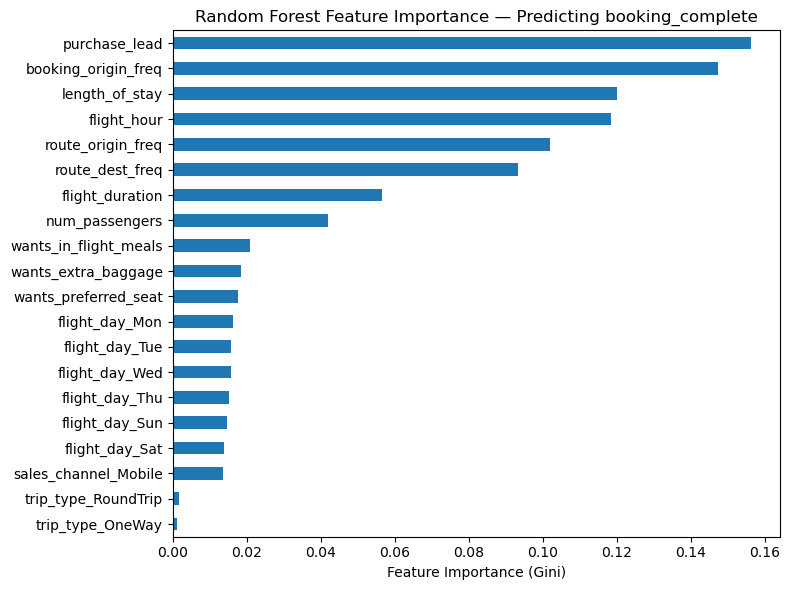

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
importances_sorted.plot(kind='barh')
plt.gca().invert_yaxis() #ranks highest importance at the very top
plt.xlabel('Feature Importance (Gini)')
plt.title('Random Forest Feature Importance — Predicting booking_complete')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()